# Model & data audit — Cordilla account scoring

Not an EDA. Each section asks one question: **is there a reason to distrust this
model or this data before it reaches a rep?** Every check ends with a verdict
(✅ fine / ⚠️ flag / 🚩 red flag) that feeds the final summary table.

`2026-08-01` is treated as "today" throughout, per the challenge brief.

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

BLUE = "#2a78d6"
ORANGE = "#eb6834"
RED = "#e34948"
GREEN = "#1baf7a"

CUTOFF = pd.Timestamp("2026-08-01")

train = pd.read_csv("../data/training_data.csv", parse_dates=["snapshot_date"])
score = pd.read_csv("../data/accounts_to_score.csv", parse_dates=["snapshot_date"])

with open("../model/model.pkl", "rb") as f:
    model = pickle.load(f)

FEATURE_COLS = ["account_type", "employee_count", "industry", "intent_score",
                "mql_count_90d", "trial_started", "trial_active_users",
                "web_touchpoints_90d", "sales_contacts_90d"]

FINDINGS = []  # (check, icon, note)

def record(check, icon, note):
    FINDINGS.append((check, icon, note))
    print(f"{icon}  {note}")

print("training_data.csv:", train.shape)
print("accounts_to_score.csv:", score.shape)

Matplotlib is building the font cache; this may take a moment.


training_data.csv: (1200, 12)
accounts_to_score.csv: (300, 11)


## What the model actually does with the inputs

Quick look at the pipeline itself before auditing the data it consumes — this
context matters for the leakage and missingness checks below.

In [2]:
print(model)
print()
imputer = model.named_steps["pre"].named_transformers_["num"]
num_cols = ["employee_count", "intent_score", "mql_count_90d", "trial_started",
            "trial_active_users", "web_touchpoints_90d", "sales_contacts_90d"]
print("Numeric imputer strategy:", imputer.strategy)
print("Median used per numeric column (incl. intent_score):")
print(pd.Series(imputer.statistics_, index=num_cols))

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['account_type', 'industry']),
                                                 ('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['employee_count',
                                                   'intent_score',
                                                   'mql_count_90d',
                                                   'trial_started',
                                                   'trial_active_users',
                                                   'web_touchpoints_90d',
                                                   'sales_contacts_90d'])])),
                ('clf',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=2,
         

**Note:** missing `intent_score` (~40% of rows, per the brief) is silently
filled with the training-set median. There is no missing-indicator flag, so the
model cannot distinguish "no vendor coverage" from "vendor coverage says
average." Whether that matters depends on whether missingness itself correlates
with conversion — checked below.

## Check 1 — Schema and identity sanity

Do both files match the documented schema, and are `account_id`s clean (no
duplicates, no overlap between the two files)?

In [3]:
expected_cols = {"account_id", "account_type", "snapshot_date", "employee_count",
                  "industry", "intent_score", "mql_count_90d", "trial_started",
                  "trial_active_users", "web_touchpoints_90d", "sales_contacts_90d"}

train_ok = expected_cols.issubset(train.columns) and "converted_within_90d" in train.columns
score_ok = expected_cols.issubset(score.columns)
train_dupes = train.account_id.duplicated().sum()
score_dupes = score.account_id.duplicated().sum()
overlap = len(set(train.account_id) & set(score.account_id))

summary = pd.DataFrame({
    "check": ["columns match spec", "duplicate account_id", "duplicate account_id", "id overlap between files"],
    "file": ["both", "training_data.csv", "accounts_to_score.csv", "both"],
    "result": [train_ok and score_ok, train_dupes, score_dupes, overlap],
})
display(summary)

if train_ok and score_ok and train_dupes == 0 and score_dupes == 0 and overlap == 0:
    record("Schema & identity", "✅", "Columns match the documented spec; no duplicate IDs; no overlap between files.")
else:
    record("Schema & identity", "🚩", "Schema or ID integrity issue found — see table above.")

,check,file,result
0,columns match spec,both,True
1,duplicate account_id,training_data.csv,0
2,duplicate account_id,accounts_to_score.csv,0
3,id overlap between files,both,0


✅  Columns match the documented spec; no duplicate IDs; no overlap between files.


## Check 2 — Does `intent_score` missingness carry signal?

~40% of rows are missing `intent_score` by design (partial vendor coverage, per
the brief). The imputer above fills these with the median and moves on. If
missingness itself correlates with conversion, that's information the model
never sees.

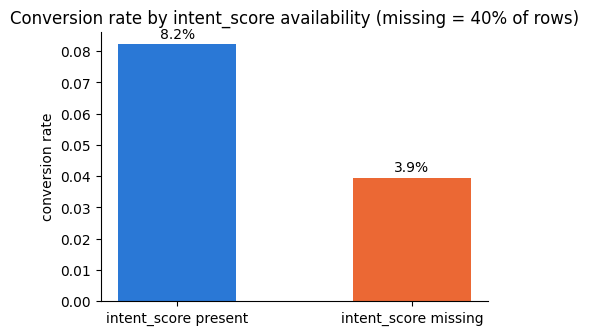

Missing rate: 40.2% (brief says ~40%)
Conversion rate — present: 8.2%, missing: 3.9% (2.1x gap)
⚠️  Missing rate matches the documented ~40%, but conversion rate is 2.1x higher when intent_score is present — missingness itself is informative, and the model's median-impute-with-no-flag approach throws that signal away.


In [4]:
train["intent_missing"] = train.intent_score.isna()
missing_rate = train.intent_missing.mean()
conv_by_missing = train.groupby("intent_missing").converted_within_90d.mean()

fig, ax = plt.subplots(figsize=(5, 3.5))
labels = ["intent_score present", "intent_score missing"]
values = [conv_by_missing.get(False, 0), conv_by_missing.get(True, 0)]
ax.bar(labels, values, color=[BLUE, ORANGE], width=0.5)
for i, v in enumerate(values):
    ax.text(i, v + 0.002, f"{v:.1%}", ha="center", fontsize=10)
ax.set_ylabel("conversion rate")
ax.set_title(f"Conversion rate by intent_score availability (missing = {missing_rate:.0%} of rows)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

ratio = conv_by_missing[False] / conv_by_missing[True]
print(f"Missing rate: {missing_rate:.1%} (brief says ~40%)")
print(f"Conversion rate — present: {conv_by_missing[False]:.1%}, missing: {conv_by_missing[True]:.1%} ({ratio:.1f}x gap)")

if ratio > 1.5:
    record("intent_score missingness", "⚠️",
           f"Missing rate matches the documented ~40%, but conversion rate is {ratio:.1f}x higher when intent_score "
           "is present — missingness itself is informative, and the model's median-impute-with-no-flag approach "
           "throws that signal away.")
else:
    record("intent_score missingness", "✅",
           "Missing rate matches documentation and doesn't meaningfully correlate with conversion.")

## Check 3 — Label integrity: base rate and outcome-window timing

Two separate questions:

1. Does the training set's conversion rate look like the real world the brief
   describes (well under 1% for cold accounts, low single digits for engaged
   ones), or does it look enriched?
2. For every row, has the 90-day outcome window actually closed as of the
   `2026-08-01` cutoff? A row whose `snapshot_date + 90 days` is still in the
   future can't have a trustworthy label yet.

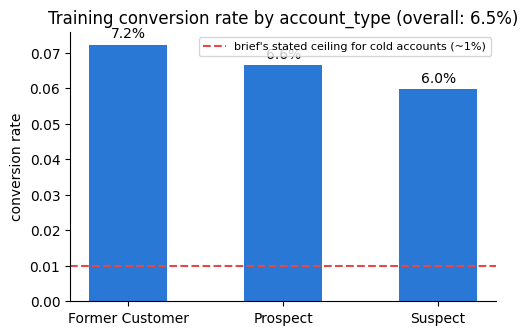

Overall training conversion rate: 6.5%
Brief's stated real-world baseline: <1% cold, low single digits engaged


In [5]:
overall_rate = train.converted_within_90d.mean()
by_type = train.groupby("account_type").converted_within_90d.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.bar(by_type.index, by_type.values, color=BLUE, width=0.5)
ax.axhline(0.01, color=RED, linestyle="--", linewidth=1.5, label="brief's stated ceiling for cold accounts (~1%)")
for i, v in enumerate(by_type.values):
    ax.text(i, v + 0.002, f"{v:.1%}", ha="center", fontsize=10)
ax.set_ylabel("conversion rate")
ax.set_title(f"Training conversion rate by account_type (overall: {overall_rate:.1%})")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

print(f"Overall training conversion rate: {overall_rate:.1%}")
print("Brief's stated real-world baseline: <1% cold, low single digits engaged")

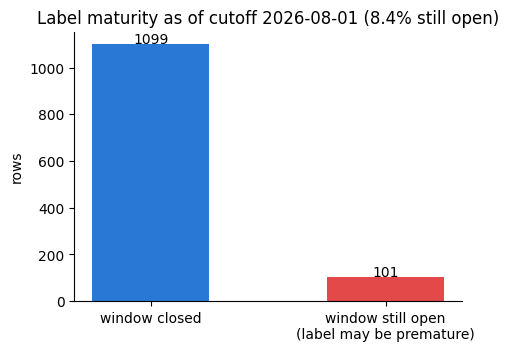

101 rows (8.4%) have snapshot_date + 90d beyond the 2026-08-01 cutoff.


,account_id,snapshot_date,converted_within_90d
0,ACC-00002,2026-07-07,0
3,ACC-00005,2026-06-22,0
9,ACC-00012,2026-05-20,0
12,ACC-00016,2026-05-06,0
93,ACC-00119,2026-05-04,0


In [6]:
window_end = train.snapshot_date + pd.Timedelta(days=90)
immature = window_end > CUTOFF
n_immature = immature.sum()
pct_immature = immature.mean()

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["window closed", "window still open\n(label may be premature)"],
       [(~immature).sum(), n_immature], color=[BLUE, RED], width=0.5)
for i, v in enumerate([(~immature).sum(), n_immature]):
    ax.text(i, v + 5, str(v), ha="center", fontsize=10)
ax.set_ylabel("rows")
ax.set_title(f"Label maturity as of cutoff 2026-08-01 ({pct_immature:.1%} still open)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

print(f"{n_immature} rows ({pct_immature:.1%}) have snapshot_date + 90d beyond the 2026-08-01 cutoff.")
display(train.loc[immature, ["account_id", "snapshot_date", "converted_within_90d"]].head(5))

In [7]:
rate_flag = overall_rate > 0.02
timing_flag = pct_immature > 0.02

if rate_flag:
    record("Label base rate", "🚩",
           f"Training conversion rate ({overall_rate:.1%}) is far above the brief's stated real-world baseline "
           "(<1% cold, low single digits engaged) — this training set is not a random sample of the real "
           "population, so predicted probabilities should not be read as calibrated real-world conversion odds.")
else:
    record("Label base rate", "✅", "Training conversion rate is broadly consistent with the stated real-world baseline.")

if timing_flag:
    record("Label window timing", "🚩",
           f"{n_immature} rows ({pct_immature:.1%}) have an outcome window that hadn't closed as of the 2026-08-01 "
           "cutoff, yet still carry a converted_within_90d label (all seen as 0 here) — these are effectively "
           "right-censored and may be mislabeled negatives, not confirmed ones.")
else:
    record("Label window timing", "✅", "All labels' 90-day windows had closed by the cutoff.")

🚩  Training conversion rate (6.5%) is far above the brief's stated real-world baseline (<1% cold, low single digits engaged) — this training set is not a random sample of the real population, so predicted probabilities should not be read as calibrated real-world conversion odds.
🚩  101 rows (8.4%) have an outcome window that hadn't closed as of the 2026-08-01 cutoff, yet still carry a converted_within_90d label (all seen as 0 here) — these are effectively right-censored and may be mislabeled negatives, not confirmed ones.


## Check 4 — Feature-timing / leakage risk

`sales_contacts_90d` and `mql_count_90d` could reflect rep effort that already
happened *because* the account looked promising, rather than an independent
predictive signal. If either dominates the model's feature importances and
also differs sharply by outcome, treat the score with more caution — it may be
echoing past human judgment rather than predicting anything new (this is the
same failure mode hypothesized for the earlier Cordilla scoring effort).

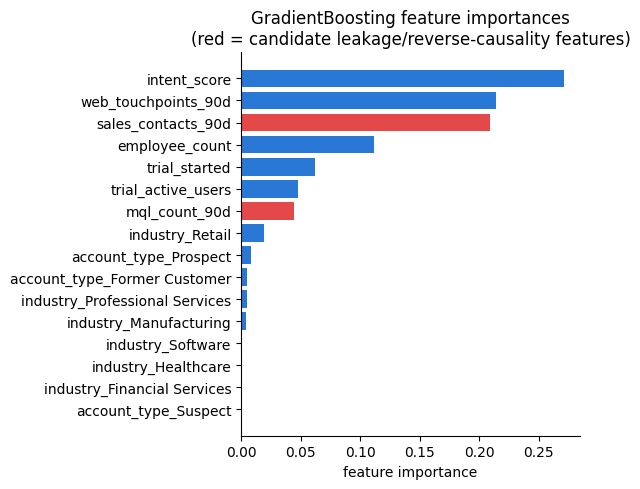

intent_score                      0.271188
web_touchpoints_90d               0.213920
sales_contacts_90d                0.209162
employee_count                    0.111344
trial_started                     0.061752
trial_active_users                0.047922
mql_count_90d                     0.044256
industry_Retail                   0.018950
account_type_Prospect             0.008604
account_type_Former Customer      0.004776
industry_Professional Services    0.004525
industry_Manufacturing            0.003601
account_type_Suspect              0.000000
industry_Financial Services       0.000000
industry_Healthcare               0.000000
industry_Software                 0.000000
dtype: float64


In [8]:
cat_encoder = model.named_steps["pre"].named_transformers_["cat"]
cat_features = list(cat_encoder.get_feature_names_out(["account_type", "industry"]))
num_features = ["employee_count", "intent_score", "mql_count_90d", "trial_started",
                 "trial_active_users", "web_touchpoints_90d", "sales_contacts_90d"]
feat_names = cat_features + num_features
importances = pd.Series(model.named_steps["clf"].feature_importances_, index=feat_names).sort_values()

fig, ax = plt.subplots(figsize=(6, 5))
colors = [RED if n in ("sales_contacts_90d", "mql_count_90d") else BLUE for n in importances.index]
ax.barh(importances.index, importances.values, color=colors)
ax.set_xlabel("feature importance")
ax.set_title("GradientBoosting feature importances\n(red = candidate leakage/reverse-causality features)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

In [9]:
means = train.groupby("converted_within_90d")[["sales_contacts_90d", "mql_count_90d", "web_touchpoints_90d"]].mean()
display(means)

sc_ratio = means.loc[1, "sales_contacts_90d"] / means.loc[0, "sales_contacts_90d"]
sc_rank = importances.rank(ascending=False)["sales_contacts_90d"]
print(f"sales_contacts_90d: converted accounts average {sc_ratio:.2f}x the contacts of non-converted, "
      f"ranked #{int(sc_rank)} of {len(importances)} features by importance.")

if sc_rank <= 3 and sc_ratio > 1.2:
    record("Feature-timing / leakage risk", "⚠️",
           f"sales_contacts_90d is the #{int(sc_rank)} most important feature and converted accounts show "
           f"{sc_ratio:.2f}x the sales contacts of non-converted ones. Direction of causality is ambiguous — "
           "high contact volume could mean the account was already flagged as promising by a rep, not that "
           "contact volume independently predicts conversion. Not extreme enough to call it clear leakage, "
           "but worth flagging before treating this as an independent signal.")
else:
    record("Feature-timing / leakage risk", "✅",
           "No feature shows a strong sign of reflecting effort already invested rather than an independent signal.")

,sales_contacts_90d,mql_count_90d,web_touchpoints_90d
converted_within_90d,,,
0,1.554367,1.090018,3.056150
1,2.192308,1.128205,3.435897


sales_contacts_90d: converted accounts average 1.41x the contacts of non-converted, ranked #3 of 16 features by importance.
⚠️  sales_contacts_90d is the #3 most important feature and converted accounts show 1.41x the sales contacts of non-converted ones. Direction of causality is ambiguous — high contact volume could mean the account was already flagged as promising by a rep, not that contact volume independently predicts conversion. Not extreme enough to call it clear leakage, but worth flagging before treating this as an independent signal.


## Check 5 — Does the scoring population look like the training population?

If `accounts_to_score.csv` is structurally different from `training_data.csv`
(account type mix, industry mix, company size), the model's learned patterns
may not transfer even if the model itself is sound.

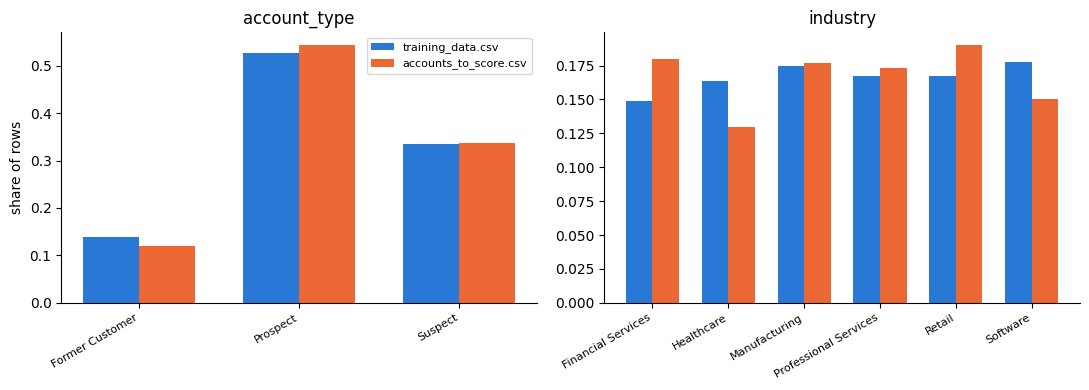

employee_count — train vs score:
mean     121.14
50%       67.00
max     4429.00
Name: employee_count, dtype: float64
mean     107.753333
50%       61.000000
max     1909.000000
Name: employee_count, dtype: float64

Largest single-category share gap (account_type/industry): 3.3%
✅  account_type, industry, and employee_count distributions are close between the two files.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col in zip(axes, ["account_type", "industry"]):
    train_share = train[col].value_counts(normalize=True)
    score_share = score[col].value_counts(normalize=True)
    cats = sorted(set(train_share.index) | set(score_share.index))
    x = np.arange(len(cats))
    w = 0.35
    ax.bar(x - w/2, [train_share.get(c, 0) for c in cats], width=w, label="training_data.csv", color=BLUE)
    ax.bar(x + w/2, [score_share.get(c, 0) for c in cats], width=w, label="accounts_to_score.csv", color=ORANGE)
    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=30, ha="right", fontsize=8)
    ax.set_title(col)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("share of rows")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

max_gap = 0
for col in ["account_type", "industry"]:
    ts = train[col].value_counts(normalize=True)
    ss = score[col].value_counts(normalize=True)
    cats = set(ts.index) | set(ss.index)
    gap = max(abs(ts.get(c, 0) - ss.get(c, 0)) for c in cats)
    max_gap = max(max_gap, gap)

print("employee_count — train vs score:")
print(train.employee_count.describe()[["mean", "50%", "max"]])
print(score.employee_count.describe()[["mean", "50%", "max"]])
print(f"\nLargest single-category share gap (account_type/industry): {max_gap:.1%}")

if max_gap > 0.15:
    record("Population match", "⚠️", f"Largest category share gap between files is {max_gap:.1%} — worth a closer look.")
else:
    record("Population match", "✅", "account_type, industry, and employee_count distributions are close between the two files.")

## Check 6 — Directional smoke test: does the score even point the right way?

Cheapest possible check before trusting anything else: run the model on the
data it was trained on and see whether known converters get scored higher on
average. This is **in-sample** (evaluated on the model's own training data, no
held-out split), so any result here is an optimistic ceiling, not a real
performance estimate — that caveat matters more than the number itself.

/var/folders/md/y7f9wc6x6kx9dkyxjsy8gm8h0000gn/T/ipykernel_48000/2923191263.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([train.loc[train.converted_within_90d == 0, "pred_proba"],


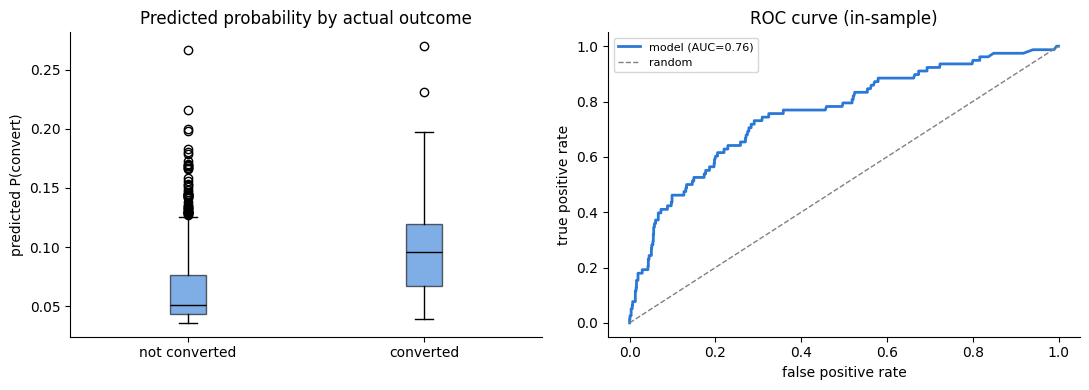

In-sample AUC: 0.759
Mean predicted probability — not converted: 6.4%, converted: 10.0%
⚠️  In-sample AUC is 0.76 — the model clearly separates converters from non-converters on the data it was trained on. That's a real directional signal, but it's an optimistic ceiling with no held-out evidence behind it, so real-world discrimination is still unverified.


In [11]:
proba = model.predict_proba(train[FEATURE_COLS])[:, 1]
train["pred_proba"] = proba
auc = roc_auc_score(train.converted_within_90d, proba)
mean_by_label = train.groupby("converted_within_90d").pred_proba.mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].boxplot([train.loc[train.converted_within_90d == 0, "pred_proba"],
                 train.loc[train.converted_within_90d == 1, "pred_proba"]],
                labels=["not converted", "converted"], patch_artist=True,
                boxprops=dict(facecolor=BLUE, alpha=0.6), medianprops=dict(color="black"))
axes[0].set_title("Predicted probability by actual outcome")
axes[0].set_ylabel("predicted P(convert)")
axes[0].spines[["top", "right"]].set_visible(False)

fpr, tpr, _ = roc_curve(train.converted_within_90d, proba)
axes[1].plot(fpr, tpr, color=BLUE, linewidth=2, label=f"model (AUC={auc:.2f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="random")
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curve (in-sample)")
axes[1].legend(fontsize=8)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"In-sample AUC: {auc:.3f}")
print(f"Mean predicted probability — not converted: {mean_by_label[0]:.1%}, converted: {mean_by_label[1]:.1%}")

if auc > 0.65:
    record("Directional smoke test", "⚠️",
           f"In-sample AUC is {auc:.2f} — the model clearly separates converters from non-converters on the data "
           "it was trained on. That's a real directional signal, but it's an optimistic ceiling with no held-out "
           "evidence behind it, so real-world discrimination is still unverified.")
else:
    record("Directional smoke test", "🚩", f"In-sample AUC is only {auc:.2f} — weak even on training data.")

## Summary — what to trust, what not to

In [12]:
summary_df = pd.DataFrame(FINDINGS, columns=["Check", "Verdict", "Finding"])
pd.set_option("display.max_colwidth", 120)
display(summary_df)

,Check,Verdict,Finding
0,Schema & identity,✅,Columns match the documented spec; no duplicate IDs; no overlap between files.
1,intent_score missingness,⚠️,"Missing rate matches the documented ~40%, but conversion rate is 2.1x higher when intent_score is present — missingn..."
2,Label base rate,🚩,"Training conversion rate (6.5%) is far above the brief's stated real-world baseline (<1% cold, low single digits eng..."
3,Label window timing,🚩,"101 rows (8.4%) have an outcome window that hadn't closed as of the 2026-08-01 cutoff, yet still carry a converted_w..."
4,Feature-timing / leakage risk,⚠️,sales_contacts_90d is the #3 most important feature and converted accounts show 1.41x the sales contacts of non-conv...
5,Population match,✅,"account_type, industry, and employee_count distributions are close between the two files."
6,Directional smoke test,⚠️,In-sample AUC is 0.76 — the model clearly separates converters from non-converters on the data it was trained on. Th...
